In [1]:
%pip install -q kaggle yfinance pandas pyarrow python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Configuration — set INPUT_TICKER before running

In [2]:
INPUT_TICKER = "AAPL"

In [3]:
SECTOR_MAP = {
    "technology": ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "AMD", "TSLA", "NVDA", "INTC"],
    "finance":    ["JPM", "GS", "MS", "BAC", "WFC", "C", "BLK", "AXP", "BK", "SCHW"],
    "energy":     ["XOM", "CVX", "COP", "EOG", "SLB", "OXY", "PSX", "VLO", "MPC", "HAL"],
    "healthcare": ["JNJ", "PFE", "MRK", "ABBV", "BMY", "AMGN", "GILD", "MDT", "ABT", "LLY"],
    "consumer":   ["WMT", "TGT", "COST", "HD", "LOW", "NKE", "MCD", "SBUX", "PG", "KO"],
    "industrial": ["CAT", "DE", "BA", "GE", "HON", "MMM", "UPS", "FDX", "LMT", "RTX"],
}

In [10]:
TICKERS = None
for sector_peers in SECTOR_MAP.values():
    if INPUT_TICKER in sector_peers:
        TICKERS = [INPUT_TICKER] + [t for t in sector_peers if t != INPUT_TICKER]
        break

if TICKERS is None:
    TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "AMD", "TSLA", "JPM", "GS"]

print(f"TICKERS resolved: {TICKERS}")

TICKERS resolved: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NFLX', 'AMD', 'TSLA', 'NVDA', 'INTC']


In [11]:
import os
from dotenv import load_dotenv

load_dotenv()

kaggle_username = os.environ.get("KAGGLE_USERNAME")
kaggle_key = os.environ.get("KAGGLE_KEY") or os.environ.get("KAGGLE_TOKEN")

if not kaggle_username or not kaggle_key:
    raise EnvironmentError("Set KAGGLE_USERNAME and KAGGLE_KEY (or KAGGLE_TOKEN) in .env")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_key

# KGAT_* tokens are OAuth tokens — enable OAuth mode before importing Kaggle SDK
if kaggle_key.startswith("KGAT_"):
    os.environ["KAGGLE_ENABLE_OAUTH"] = "true"

import kaggle  # import AFTER env vars are set — kaggle.__init__ calls authenticate() at import time
kaggle.api.authenticate()
print("Kaggle authenticated successfully")

Kaggle authenticated successfully


In [12]:
import tempfile

_temp_dir = tempfile.mkdtemp(prefix="kaggle_news_")
print(f"Downloading Kaggle dataset to temp dir: {_temp_dir}")
try:
    kaggle.api.dataset_download_files(
        "davidmckinley/all-the-news-dataset",
        path=_temp_dir,
        unzip=True,
    )
except Exception as e:
    if "403" in str(e):
        raise RuntimeError(
            "Kaggle returned 403 Forbidden. You must accept the dataset licence "
            "in a browser before the API can download it.\n"
            "Visit: https://www.kaggle.com/datasets/davidmckinley/all-the-news-dataset "
            "and click Download while logged in, then re-run this cell."
        ) from e
    raise
print("Download complete")

Dataset URL: https://www.kaggle.com/datasets/davidmckinley/all-the-news-dataset
Download complete


In [13]:
import glob
import shutil
import pandas as pd
from pathlib import Path

csv_files = glob.glob(f"{_temp_dir}/**/*.csv", recursive=True)
print(f"Found CSV files: {[Path(f).name for f in csv_files]}")

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in download directory {_temp_dir}. "
        "Check that the Kaggle dataset downloaded correctly and try again."
    )

df_raw = pd.read_csv(csv_files[0], low_memory=False)
print(f"Raw dataset: {len(df_raw)} rows, columns: {list(df_raw.columns)}")

shutil.rmtree(_temp_dir, ignore_errors=True)
del _temp_dir
print("Temp download dir cleaned up")

Found CSV files: ['all-the-news-2-1.csv']
Raw dataset: 2688879 rows, columns: ['Unnamed: 0.1', 'Unnamed: 0', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication']
Temp download dir cleaned up


In [14]:
ALLOWED_SOURCES = {"Reuters", "Forbes", "Business Insider"}

pub_col = "publication"
print(f"Rows before source filter: {len(df_raw)}")
df_filtered = df_raw[df_raw[pub_col].isin(ALLOWED_SOURCES)].copy()
print(f"Rows after source filter:  {len(df_filtered)}")

Rows before source filter: 2688879
Rows after source filter:  898047


In [18]:
NAME_TO_TICKER = {
    # Technology
    r"Apple":                          "AAPL",
    r"Microsoft":                      "MSFT",
    r"Google|Alphabet":                "GOOGL",
    r"Amazon":                         "AMZN",
    r"Meta|Facebook":                  "META",
    r"Netflix":                        "NFLX",
    r"AMD|Advanced Micro Devices":     "AMD",
    r"Tesla":                          "TSLA",
    r"NVIDIA|Nvidia":                  "NVDA",
    r"Intel":                          "INTC",
    # Finance
    r"JPMorgan|JP\s+Morgan":           "JPM",
    r"Goldman Sachs":                  "GS",
    r"Morgan Stanley":                 "MS",
    r"Bank of America":                "BAC",
    r"Wells Fargo":                    "WFC",
    r"Citigroup|Citi":                 "C",
    r"BlackRock":                      "BLK",
    r"American Express|AmEx":          "AXP",
    r"Bank of New York Mellon|BNY Mellon": "BK",
    r"Charles Schwab|Schwab":          "SCHW",
    # Energy
    r"ExxonMobil|Exxon\s+Mobil|Exxon": "XOM",
    r"Chevron":                        "CVX",
    r"ConocoPhillips|Conoco":          "COP",
    r"EOG Resources|EOG":              "EOG",
    r"Schlumberger|SLB":               "SLB",
    r"Occidental|OXY":                 "OXY",
    r"Phillips 66":                    "PSX",
    r"Valero":                         "VLO",
    r"Marathon Petroleum|Marathon":    "MPC",
    r"Halliburton":                    "HAL",
    # Healthcare
    r"Johnson\s*&\s*Johnson|J&J":      "JNJ",
    r"Pfizer":                         "PFE",
    r"Merck":                          "MRK",
    r"AbbVie":                         "ABBV",
    r"Bristol.Myers Squibb|Bristol Myers": "BMY",
    r"Amgen":                          "AMGN",
    r"Gilead":                         "GILD",
    r"Medtronic":                      "MDT",
    r"Abbott(?!\s+Laboratories\s+of)":  "ABT",
    r"Eli Lilly|Lilly":                "LLY",
    # Consumer
    r"Walmart|Wal.Mart":               "WMT",
    r"Target":                         "TGT",
    r"Costco":                         "COST",
    r"Home Depot":                     "HD",
    r"Lowe.s":                         "LOW",
    r"Nike":                           "NKE",
    r"McDonald.s":                     "MCD",
    r"Starbucks":                      "SBUX",
    r"Procter\s*&\s*Gamble|P&G":       "PG",
    r"Coca.Cola|Coca Cola":            "KO",
    # Industrial
    r"Caterpillar":                    "CAT",
    r"Deere|John Deere":               "DE",
    r"Boeing":                         "BA",
    r"General Electric|GE":            "GE",
    r"Honeywell":                      "HON",
    r"3M":                             "MMM",
    r"UPS|United Parcel Service":       "UPS",
    r"FedEx":                          "FDX",
    r"Lockheed Martin":                "LMT",
    r"Raytheon":                       "RTX",
}

In [19]:
import re

def find_tickers(text: str, name_to_ticker: dict) -> list:
    if not isinstance(text, str):
        return []
    matched = []
    for pattern, ticker in name_to_ticker.items():
        if re.search(r'\b(?:' + pattern + r')\b', text, re.IGNORECASE):
            matched.append(ticker)
    return sorted(set(matched))

In [20]:
title_col = "title"
content_col = "article"  # All The News 2.1 uses 'article', not 'content'

df_filtered["full_text"] = (
    df_filtered[title_col].fillna("") + " " + df_filtered[content_col].fillna("")
)

df_filtered["matched_tickers"] = df_filtered["full_text"].apply(
    lambda text: find_tickers(text, NAME_TO_TICKER)
)

df_filtered = df_filtered[df_filtered["matched_tickers"].map(len) > 0].copy()
print(f"Rows with at least one ticker match: {len(df_filtered)}")

Rows with at least one ticker match: 173458


In [21]:
df_exploded = df_filtered.explode("matched_tickers").rename(
    columns={"matched_tickers": "ticker"}
)
df_exploded = df_exploded[df_exploded["ticker"].isin(TICKERS)].copy()
print(f"Rows after explode and TICKERS filter: {len(df_exploded)}")

tickers_with_news = set(df_exploded["ticker"].unique())
for ticker in TICKERS:
    if ticker not in tickers_with_news:
        print(f"WARNING: {ticker} has zero article matches — will be absent from raw_news.parquet")

Rows after explode and TICKERS filter: 98879


In [25]:
import bisect
import datetime

# pandas.bdate_range gives all business days (Mon–Fri), skipping weekends.
# US holidays are not excluded but the difference is negligible for daily sentiment alignment.
bday_range = pd.bdate_range(start="2013-01-01", end="2021-12-31")
trading_days = sorted(bday_range.date.tolist())

def next_trading_day(d):
    if isinstance(d, str):
        d = datetime.date.fromisoformat(d)
    elif hasattr(d, "date"):
        d = d.date()
    idx = bisect.bisect_left(trading_days, d)
    if idx < len(trading_days) and trading_days[idx] == d:
        return d
    if idx < len(trading_days):
        return trading_days[idx]
    return trading_days[-1]

df_exploded["date"] = pd.to_datetime(df_exploded["date"], errors="coerce")
df_exploded = df_exploded.dropna(subset=["date"])

original_dates = df_exploded["date"].dt.date.copy()
df_exploded["date"] = df_exploded["date"].dt.date.apply(next_trading_day)
shifted = (df_exploded["date"] != original_dates).sum()
print(f"Dates shifted to next business day: {shifted}")

Dates shifted to next business day: 5789


In [26]:
df_news = df_exploded[[title_col, "ticker", pub_col, "date"]].rename(
    columns={title_col: "headline", pub_col: "source"}
)[["date", "ticker", "headline", "source"]].copy()

df_news["date"] = pd.to_datetime(df_news["date"])

os.makedirs("data", exist_ok=True)
df_news.to_parquet("data/raw_news.parquet", index=False)
print(f"Saved data/raw_news.parquet — {len(df_news)} rows")

Saved data/raw_news.parquet — 73936 rows


In [27]:
import numpy as np
import yfinance as yf

try:
    df_wide = yf.download(TICKERS, start="2013-01-01", end="2020-12-31", auto_adjust=True)
    print("yfinance download complete")
    for ticker in TICKERS:
        try:
            close_col = ("Close", ticker) if isinstance(df_wide.columns, pd.MultiIndex) else "Close"
            if df_wide[close_col].dropna().empty:
                print(f"WARNING: {ticker} returned empty data")
            else:
                print(f"  {ticker}: {df_wide[close_col].dropna().shape[0]} rows")
        except KeyError:
            print(f"WARNING: {ticker} not found in download result")
except Exception as e:
    print(f"Download error: {e}")
    raise

[*********************100%***********************]  10 of 10 completed

yfinance download complete
  AAPL: 2014 rows
  MSFT: 2014 rows
  GOOGL: 2014 rows
  AMZN: 2014 rows
  META: 2014 rows
  NFLX: 2014 rows
  AMD: 2014 rows
  TSLA: 2014 rows
  NVDA: 2014 rows
  INTC: 2014 rows


In [28]:
df_long = df_wide.stack(level=1).reset_index()
df_long.columns.name = None

rename_map = {
    "Date": "date",
    "Ticker": "ticker",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume",
}
df_long = df_long.rename(columns=rename_map)

# yfinance stack puts ticker in level 1 — column may be named differently
level_name = df_wide.columns.names[1] if hasattr(df_wide.columns, 'names') else None
if level_name and level_name not in rename_map and level_name in df_long.columns:
    df_long = df_long.rename(columns={level_name: "ticker"})

df_long = df_long[["date", "ticker", "open", "high", "low", "close", "volume"]].copy()
print(f"Long format: {len(df_long)} rows, columns: {list(df_long.columns)}")

Long format: 20140 rows, columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']


/var/folders/4k/v3c36srx6c3gb0ztjb5l3dyr0000gn/T/ipykernel_55589/2778475626.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df_wide.stack(level=1).reset_index()


In [29]:
df_long = df_long.sort_values(["ticker", "date"]).reset_index(drop=True)
df_long["log_return"] = (
    df_long.groupby("ticker")["close"]
    .transform(lambda s: np.log(s / s.shift(1)))
)
print(f"Log returns computed; NaN count (expected ~{len(TICKERS)}): {df_long['log_return'].isna().sum()}")

Log returns computed; NaN count (expected ~10): 10


In [30]:
df_prices = df_long.copy()
df_prices["date"] = pd.to_datetime(df_prices["date"])
os.makedirs("data", exist_ok=True)
df_prices.to_parquet("data/raw_prices.parquet", index=False)
print(f"Saved data/raw_prices.parquet — {len(df_prices)} rows, {df_prices['ticker'].nunique()} tickers")

Saved data/raw_prices.parquet — 20140 rows, 10 tickers


In [31]:
df_news_summary = pd.read_parquet("data/raw_news.parquet")
df_prices_summary = pd.read_parquet("data/raw_prices.parquet")

print("Headlines per ticker:")
print(df_news_summary.groupby("ticker").size().sort_values(ascending=False).to_string())

print(f"\nPrice data: {df_prices_summary['date'].min().date()} to {df_prices_summary['date'].max().date()}")

Headlines per ticker:
ticker
META     23090
AMZN     13189
GOOGL    11087
AAPL     10822
MSFT      4885
NFLX      4288
TSLA      3908
INTC      1624
NVDA       625
AMD        418

Price data: 2013-01-02 to 2020-12-30


## EDA — Exploratory Data Analysis

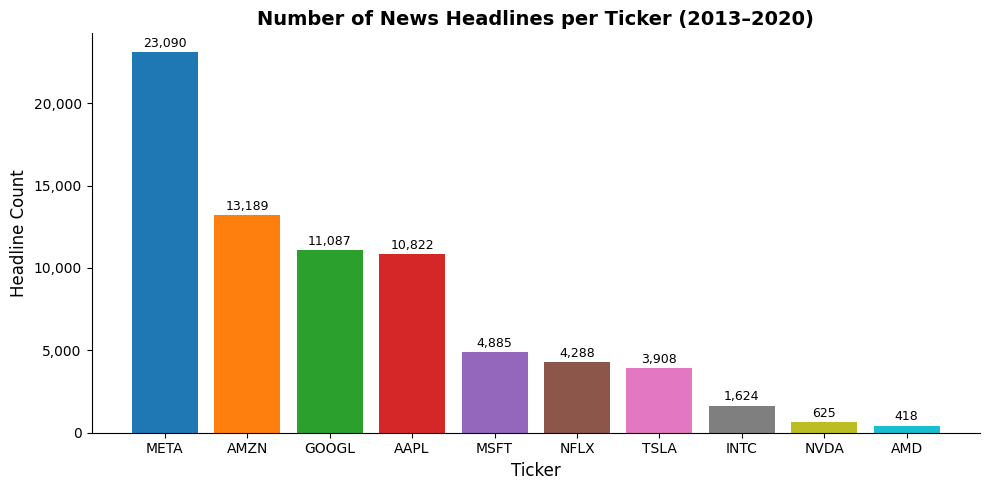

Saved outputs/eda_01_headlines_per_ticker.png


In [1]:

# EDA 1 — Headlines per Ticker (bar chart)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

df_news_eda = pd.read_parquet("data/raw_news.parquet")
counts = df_news_eda.groupby("ticker").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors[:len(counts)])
ax.set_title("Number of News Headlines per Ticker (2013–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Ticker", fontsize=12)
ax.set_ylabel("Headline Count", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f"{val:,}", ha='center', va='bottom', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_01_headlines_per_ticker.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_01_headlines_per_ticker.png")


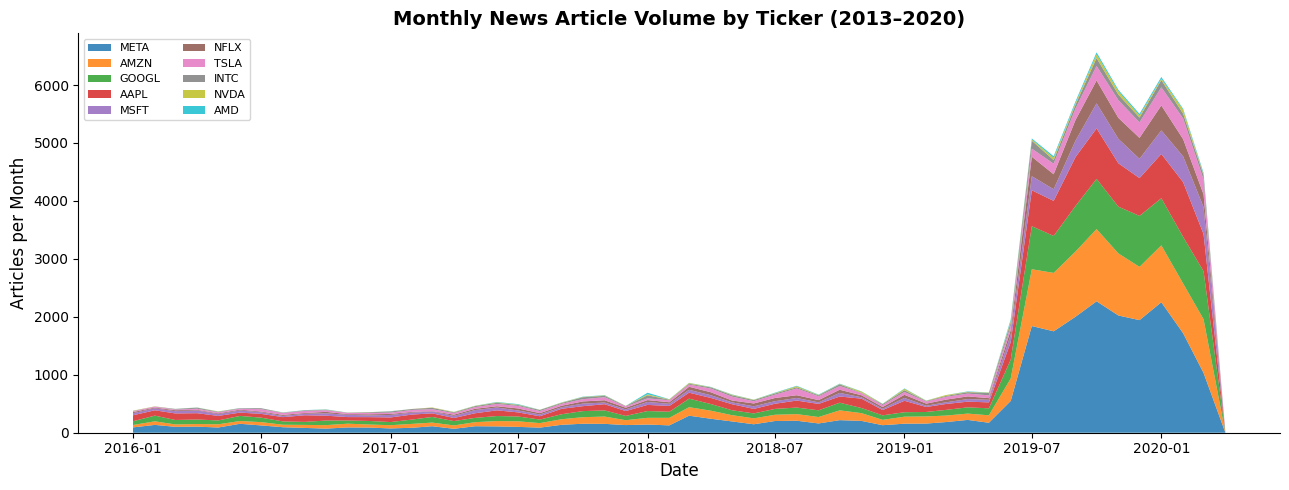

Saved outputs/eda_02_article_volume_over_time.png


In [2]:

# EDA 2 — Article Volume Over Time (monthly, stacked area)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_news_eda = pd.read_parquet("data/raw_news.parquet")
df_news_eda["date"] = pd.to_datetime(df_news_eda["date"])
df_news_eda["month"] = df_news_eda["date"].dt.to_period("M")

monthly = (df_news_eda.groupby(["month", "ticker"])
           .size()
           .reset_index(name="count")
           .pivot(index="month", columns="ticker", values="count")
           .fillna(0))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
tickers_sorted = monthly.sum().sort_values(ascending=False).index
ax.stackplot(monthly.index, [monthly[t] for t in tickers_sorted],
             labels=tickers_sorted, alpha=0.85)
ax.set_title("Monthly News Article Volume by Ticker (2013–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Articles per Month", fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_02_article_volume_over_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_02_article_volume_over_time.png")


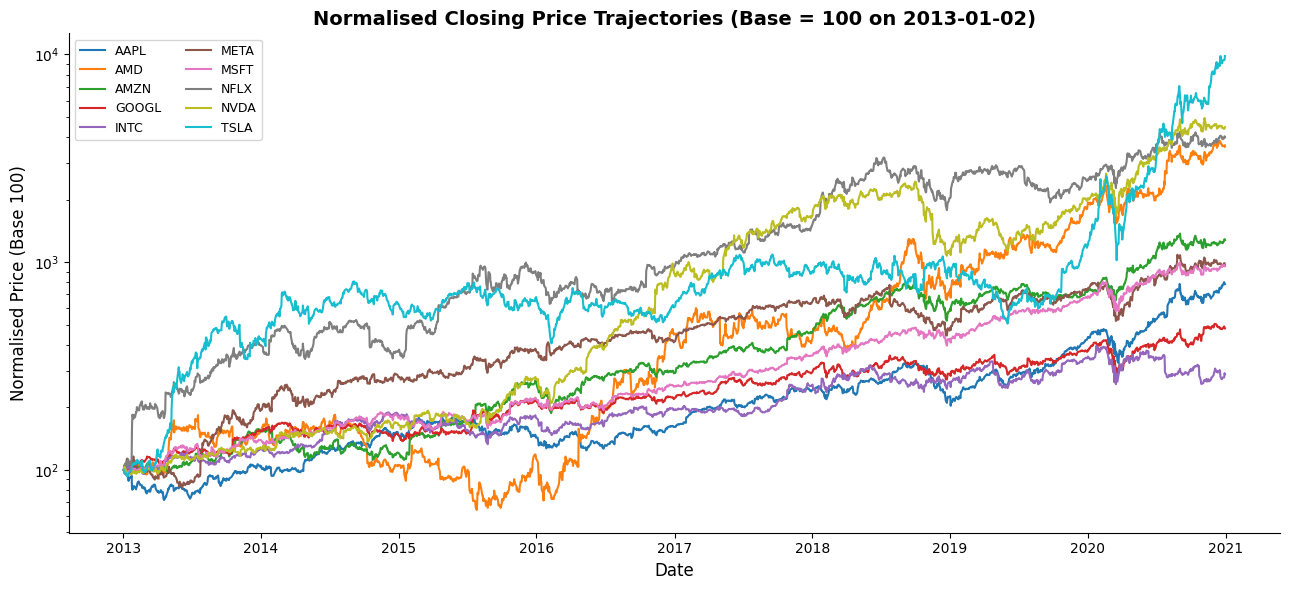

Saved outputs/eda_03_normalised_price_history.png


In [3]:

# EDA 3 — Normalised Closing Price History (all tickers, log-scale)
import matplotlib.pyplot as plt
import pandas as pd

df_prices_eda = pd.read_parquet("data/raw_prices.parquet")
df_prices_eda["date"] = pd.to_datetime(df_prices_eda["date"])

fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.tab10.colors

for idx, ticker in enumerate(sorted(df_prices_eda["ticker"].unique())):
    sub = df_prices_eda[df_prices_eda["ticker"] == ticker].sort_values("date")
    base = sub["close"].iloc[0]
    ax.plot(sub["date"], sub["close"] / base * 100,
            label=ticker, color=colors[idx % 10], linewidth=1.5)

ax.set_title("Normalised Closing Price Trajectories (Base = 100 on 2013-01-02)", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalised Price (Base 100)", fontsize=12)
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.set_yscale("log")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_03_normalised_price_history.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_03_normalised_price_history.png")


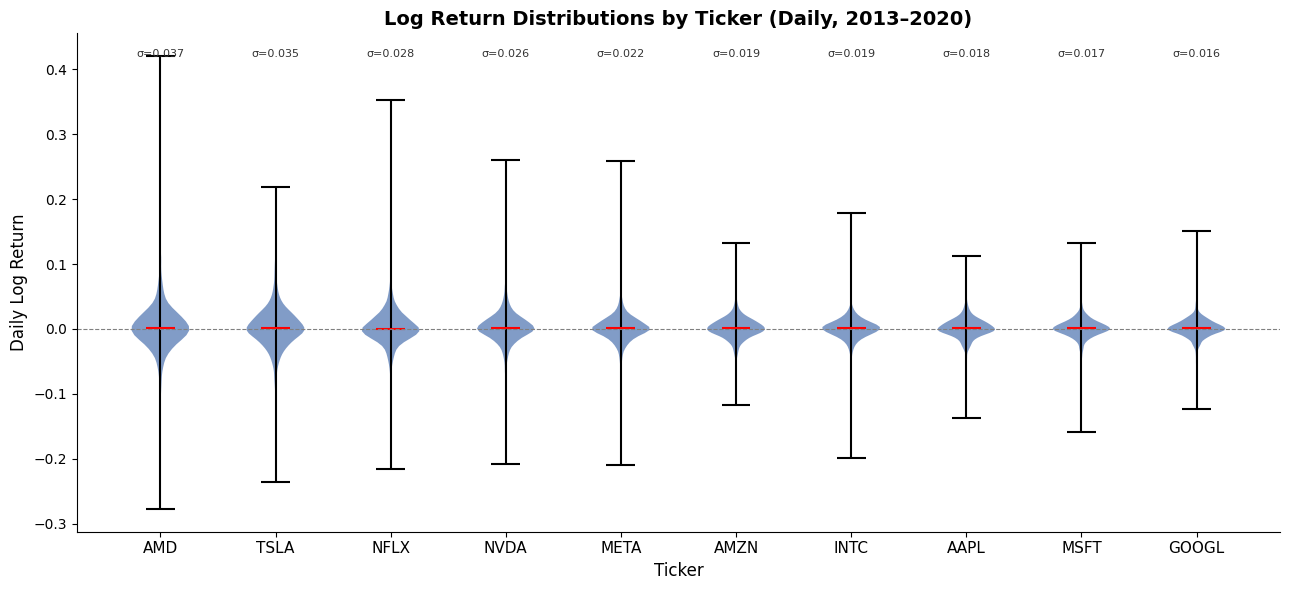

Saved outputs/eda_04_log_return_distributions.png


In [4]:

# EDA 4 — Log Return Distributions (violin plot per ticker)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_prices_eda = pd.read_parquet("data/raw_prices.parquet")
tickers_ordered = (df_prices_eda.groupby("ticker")["log_return"]
                   .std().sort_values(ascending=False).index.tolist())

data_by_ticker = [df_prices_eda.loc[df_prices_eda["ticker"] == t, "log_return"].dropna().values
                  for t in tickers_ordered]

fig, ax = plt.subplots(figsize=(13, 6))
parts = ax.violinplot(data_by_ticker, positions=range(len(tickers_ordered)),
                     showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.7)
parts['cmedians'].set_color('red')
parts['cmins'].set_color('black')
parts['cmaxes'].set_color('black')
parts['cbars'].set_color('black')

ax.set_xticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered, fontsize=11)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title("Log Return Distributions by Ticker (Daily, 2013–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Ticker", fontsize=12)
ax.set_ylabel("Daily Log Return", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Annotate std dev
for i, t in enumerate(tickers_ordered):
    std = df_prices_eda.loc[df_prices_eda["ticker"] == t, "log_return"].std()
    ax.text(i, ax.get_ylim()[1] * 0.92, f"σ={std:.3f}", ha='center', fontsize=8, color='#333')

plt.tight_layout()
plt.savefig("outputs/eda_04_log_return_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_04_log_return_distributions.png")


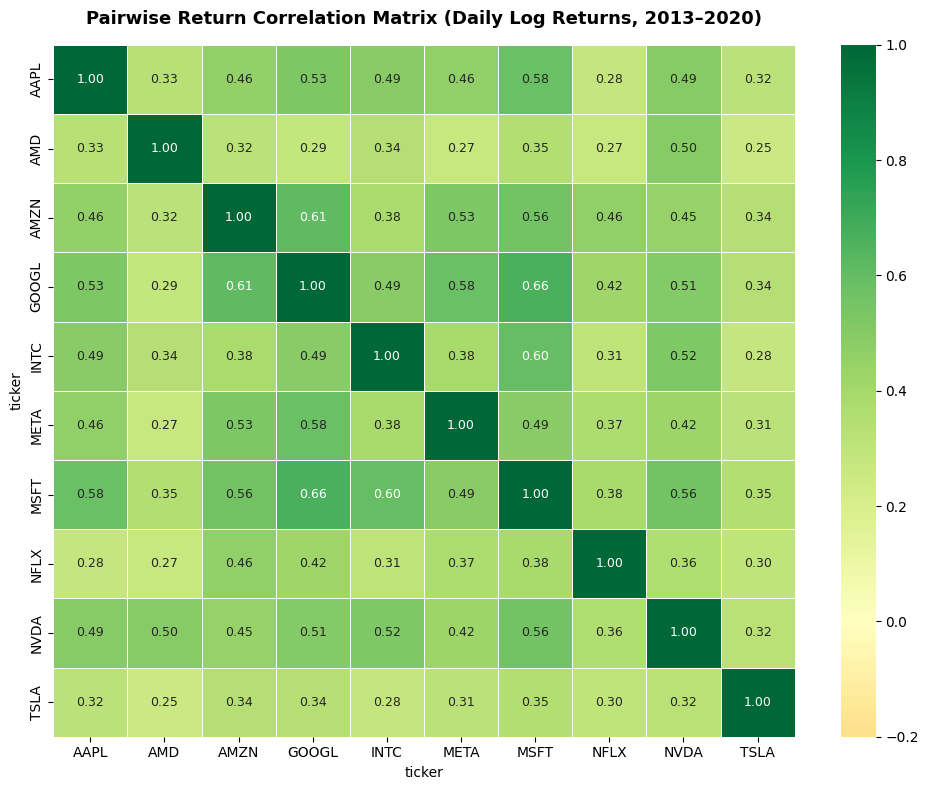

Saved outputs/eda_05_return_correlation_matrix.png


In [5]:

# EDA 5 — Return Correlation Matrix (heatmap)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_prices_eda = pd.read_parquet("data/raw_prices.parquet")
ret_pivot = df_prices_eda.pivot(index="date", columns="ticker", values="log_return")
corr = ret_pivot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = (corr == 1.0)  # mask diagonal for clarity
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-0.2, vmax=1.0,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Pairwise Return Correlation Matrix (Daily Log Returns, 2013–2020)",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("outputs/eda_05_return_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved outputs/eda_05_return_correlation_matrix.png")
